In [1]:
# In this first block I define all the relevant functions needed for the analysis of the non-equilibrium thermodynamics of the BJJ

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import tqdm
from tqdm import tqdm
import matplotlib.ticker as ticker


def twomode_bose_hubbard_hamiltonian_vectorized(N, K, U):
    dim = N + 1
    n1 = np.arange(dim)
    n2 = N - n1
    diag = (U / 4.0) * (n1 - n2) ** 2
    H = np.diag(diag)
    k_idx = np.arange(1, dim)
    off_vals = -0.5 * K * np.sqrt(k_idx * (N - k_idx + 1))
    H += np.diag(off_vals, k=1) + np.diag(off_vals, k=-1)
    return H

def numerical_phases(V):
    for i in range(V.shape[1]):
        idx = np.argmax(np.abs(V[:, i]))
        phase = np.sign(V[idx, i])
        if phase != 0:
            V[:, i] *= phase
    return V


def Average_Work(H_i,H_f,state_i):
   
    W=np.vdot(state_i,H_f.dot(state_i))-np.vdot(state_i,H_i.dot(state_i))

    return W

def Amplitudes(H_i,H_f):
    E_i,V_i=eigh(H_i)
    E_f,V_f=eigh(H_f)
    V_i = numerical_phases(V_i)
    V_f = numerical_phases(V_f)
    return V_f.T @ V_i,E_i,E_f,V_i,V_f


def ClassicalBound(H_i,H_f,state_i):
    Lambda,E_i,E_f,V_i,V_f=Amplitudes(H_i,H_f)
    p_jk=(np.abs(Lambda)**2)*np.abs(V_i.T@state_i)**2
    p_k=np.abs(V_f.T @ state_i)**2
    dim=len(E_i)
    w_bound=0
    for j in range(dim):
        for k in range(dim):
            if E_i[j] >= E_f[k]:
                w= (E_i[j] - E_f[k]) * np.sqrt(p_jk[k, j] * p_k[k])
                w_bound += w
                
    return w_bound

def omega_plasma(N,U,K):
    return K*np.sqrt(N*U/K+1)

def Average_WorkTheory(alpha,delta_phi,U_i,U_f,N,K):

    omega_i=omega_plasma(N,U_i,K)
    beta=np.sqrt(1-alpha**2)*np.exp(1j*delta_phi)
    w_D = (N / 2.0) * ((U_f-U_i) / omega_i) * K * (2 * np.abs(beta)**2 + 0.5)
    w_C = (N * np.sqrt(2) / 2.0) * ((U_f-U_i)/ omega_i) * K * np.real(alpha * np.conj(beta))
    
    return w_C+w_D

def Work_variance(H_i,H_f,state_i):
    work_op = H_f - H_i
    work_op_squared = work_op @ work_op
    var_w=np.vdot(state_i,work_op_squared.dot(state_i))-np.vdot(state_i,work_op.dot(state_i))**2
 
    return var_w



In [ ]:
# This is the core of the simulation. By using exact diagonalization (see functions in the previous block), we evaluate the average work, the work variance and the difference 
# between the classical bound on work extraction and the extractable unperturbed work in the KDQ formalism.
K=10
U_i, U_f, N = 0.1*K, 0.0, 100

alpha = np.linspace(0, 1, 100)
delta_phi= np.linspace(0,  2*np.pi, 100)

bound_matrix = np.zeros((len(alpha), len(delta_phi)))
work_matrix =np.zeros((len(alpha),len(delta_phi)))
variance_matrix=np.zeros((len(alpha),len(delta_phi)))
H_i=twomode_bose_hubbard_hamiltonian_vectorized(N,K,U_i)
H_f=twomode_bose_hubbard_hamiltonian_vectorized(N,K,U_f)
Lambda,E_i,E_f,V_i,V_f=Amplitudes(H_i,H_f)
V_i=numerical_phases(V_i)
V_f=numerical_phases(V_f)


for i, a in tqdm(enumerate(alpha)):
    for j, phi in enumerate(delta_phi):

        state_i = a * V_i[:, 0]+ np.sqrt(1 - a**2 + 1e-15) * np.exp(1j * phi) * V_i[:, 2]
        state_i /= np.linalg.norm(state_i)
    
        bound_matrix[i, j] = ClassicalBound(H_i,H_f,state_i)
        work_matrix[i, j] =Average_Work(H_i,H_f,state_i)
        variance_matrix[i,j]=Work_variance(H_i,H_f,state_i)


0it [00:00, ?it/s]C:\Users\Mattia\AppData\Local\Temp/ipykernel_18536/3557541269.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  work_matrix[i, j] =Average_Work(H_i,H_f,state_i)
C:\Users\Mattia\AppData\Local\Temp/ipykernel_18536/3557541269.py:27: ComplexWarning: Casting complex values to real discards the imaginary part
  variance_matrix[i,j]=Work_variance(H_i,H_f,state_i)
38it [02:15,  3.58s/it]

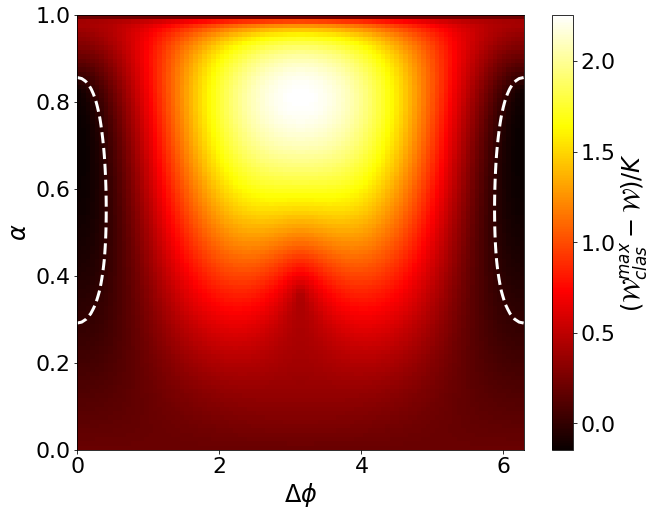

In [4]:
# We plot the difference between the classical bound on work extraction and the extractable unperturbed work


total_matrix=work_matrix+bound_matrix
X,Y=np.meshgrid(delta_phi,alpha)
plt.figure(figsize=(10, 8))

img = plt.imshow(total_matrix/K, aspect='auto', origin='lower', 
                 extent=[delta_phi.min(), delta_phi.max(), alpha.min(), alpha.max()],
                 cmap='hot')
cbar = plt.colorbar(img)

cbar.set_label(r'$(\mathcal{W}^{max}_{clas} - \mathcal{W})/K$', fontsize=24)


cbar.ax.tick_params(labelsize=22)

#plt.contour(X,Y, total_matrix, levels=[0], colors='green', linestyles='-', linewidths=3)
plt.contour(X, Y, total_matrix, levels=[0], colors='white', linestyles='--', linewidths=3)
plt.xlabel(r'$\Delta \phi$',fontsize=24)
plt.ylabel(r'$\alpha$',fontsize=24)
plt.tick_params(axis="both",labelsize=22)
plt.savefig('contextuality.pdf', format='pdf', bbox_inches='tight')

plt.show()


In [ ]:
M=bound_matrix+work_matrix
index_min= np.nanargmin(M)
row_idx, col_idx = np.unravel_index(index_min,M.shape)

maximum_violation= M[row_idx, col_idx]/K
best_alpha = alpha[row_idx]
best_dphi = delta_phi[col_idx]


print(f"Valore massimo violazione contestualità: {maximum_violation:.6f}")
print(f"Alpha corrispondente: {best_alpha:.6f}")
print(f"Delta Phi corrispondente: {best_dphi:.6f}")


Valore massimo W: -0.146082
Alpha corrispondente: 0.696970
Delta Phi corrispondente: 0.000000


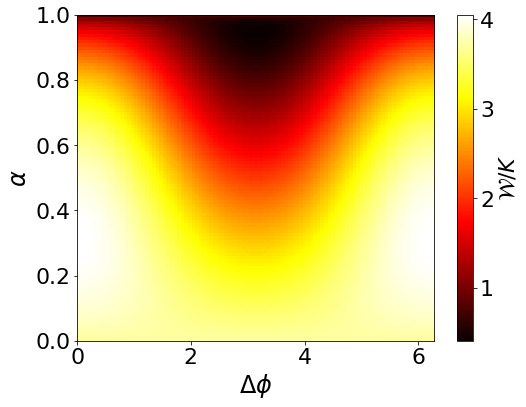

In [5]:
# Plot of the average extractable work
plt.figure(figsize=(8, 6))

img = plt.imshow(-work_matrix/K, aspect='auto', origin='lower', 
                 extent=[delta_phi.min(), delta_phi.max(), alpha.min(), alpha.max()],
                 cmap='hot')
cbar = plt.colorbar(img)

cbar.set_label(r'$ \mathcal{W}/K$', fontsize=22)

cbar.ax.tick_params(labelsize=22)

plt.xlabel(r'$\Delta \phi$',fontsize=24)
plt.ylabel(r'$\alpha$',fontsize=24)
plt.tick_params(axis="both",labelsize=22)
plt.savefig('average_work.pdf', format='pdf', bbox_inches='tight')
plt.show()

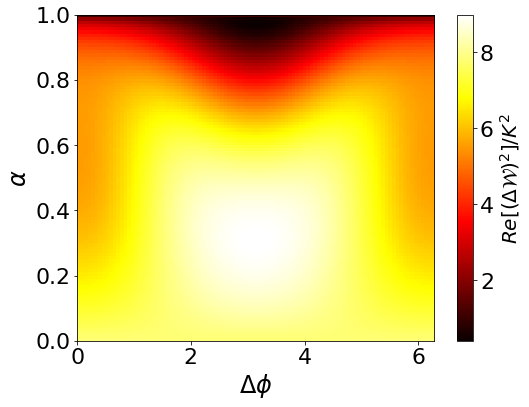

In [6]:
# Plot of the work variance

plt.figure(figsize=(8, 6))

img = plt.imshow(variance_matrix/K**2, aspect='auto', origin='lower', 
                 extent=[delta_phi.min(), delta_phi.max(), alpha.min(), alpha.max()],
                 cmap='hot')
cbar = plt.colorbar(img)

cbar.set_label(r'$ Re[(\Delta\mathcal{W})^2]/K^2$', fontsize=20)

cbar.ax.tick_params(labelsize=22)

plt.xlabel(r'$\Delta \phi$',fontsize=24)
plt.ylabel(r'$\alpha$',fontsize=24)
plt.tick_params(axis="both",labelsize=22)
plt.savefig('variance_work.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [15]:
# Trovo l'indice della matrice -work_matrix che contiene il valore massimo ed i corrispondenti alpha e differenza di fase

index_max = np.nanargmax(-work_matrix)
row_idx, col_idx = np.unravel_index(index_max,work_matrix.shape)

maximum_work = -work_matrix[row_idx, col_idx]/K
best_alpha = alpha[row_idx]
best_dphi = delta_phi[col_idx]
variance_atmaxwork=variance_matrix[row_idx, col_idx]/K**2

print(f"Valore massimo W: {maximum_work:.6f}")
print(f"Valore massimo W teorico: {-Average_WorkTheory(0.303030,0,U_i,U_f,N,K)/K:.6f}")
print(f"Alpha corrispondente: {best_alpha:.6f}")
print(f"Delta Phi corrispondente: {best_dphi:.6f}")
print(f"Varianze per lo stato che massimizza il lavoro: {variance_atmaxwork:.6f}")



Valore massimo W: 4.048096
Valore massimo W teorico: 4.107707
Alpha corrispondente: 0.303030
Delta Phi corrispondente: 0.000000
Varianze per lo stato che massimizza il lavoro: 6.059155


In [ ]:

index_max = np.nanargmax(bound_matrix+work_matrix)
row_idx, col_idx = np.unravel_index(index_max,work_matrix.shape)

maximum_work = -work_matrix[row_idx, col_idx]/K
best_alpha = alpha[row_idx]
best_dphi = delta_phi[col_idx]
variance_atmaxwork=variance_matrix[row_idx, col_idx]/K**2

print(f"Valore massimo W: {maximum_work:.6f}")
print(f"Valore massimo W teorico: {-Average_WorkTheory(0.303030,0,U_i,U_f,N,K)/K:.6f}")
print(f"Alpha corrispondente: {best_alpha:.6f}")
print(f"Delta Phi corrispondente: {best_dphi:.6f}")
print(f"Varianze per lo stato che massimizza il lavoro: {variance_atmaxwork:.6f}")

In [16]:

index_min = np.nanargmin(variance_matrix)
row_idx, col_idx = np.unravel_index(index_min, variance_matrix.shape)


minimum_variance = variance_matrix[row_idx, col_idx] / K**2
best_alpha = alpha[row_idx]
best_dphi = delta_phi[col_idx]
work_atminvariance = -work_matrix[row_idx, col_idx] / K


print(f"Valore minimo varianza: {minimum_variance:.6f}")
print(f"Alpha corrispondente: {best_alpha:.6f}")
print(f"Delta Phi corrispondente: {best_dphi:.6f}")
print(f"Lavoro per lo stato con varianza minima: {work_atminvariance:.6f}")

Valore minimo varianza: 0.413620
Alpha corrispondente: 0.979798
Delta Phi corrispondente: 3.109859
Lavoro per lo stato con varianza minima: 0.452956


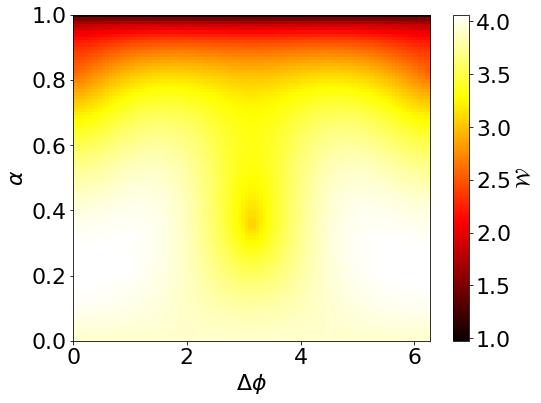

In [ ]:
# Plot of the classical bound on work extraction 

plt.figure(figsize=(8, 6))

img = plt.imshow(bound_matrix/K, aspect='auto', origin='lower', 
                 extent=[delta_phi.min(), delta_phi.max(), alpha.min(), alpha.max()],
                 cmap='hot')
cbar = plt.colorbar(img)

cbar.set_label(r'$ \mathcal{W}$', fontsize=20)

cbar.ax.tick_params(labelsize=22)

plt.xlabel(r'$\Delta \phi$',fontsize=22)
plt.ylabel(r'$\alpha$',fontsize=22)
plt.tick_params(axis="both",labelsize=22)
plt.show()

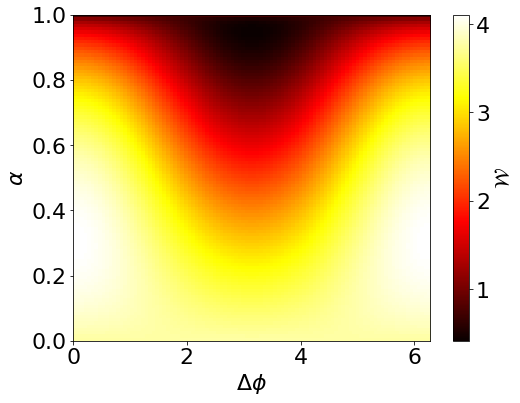

In [ ]:
# Plot of extractable work based on the HP approximation

work_matrix_theory=np.zeros((len(alpha),len(delta_phi)))
for i,a in (enumerate(alpha)):
    for j,phi in(enumerate(delta_phi)):
        state_i = a * V_i[:, 0] + np.sqrt(1 - a**2 + 1e-15) * np.exp(1j * phi) * V_i[:, 2]
        state_i /= np.linalg.norm(state_i)
        work_matrix_theory[i,j]=Average_WorkTheory(a,phi,U_i,U_f,N,K)

plt.figure(figsize=(8, 6))

img = plt.imshow(-work_matrix_theory/K, aspect='auto', origin='lower', 
                 extent=[delta_phi.min(), delta_phi.max(), alpha.min(), alpha.max()],
                 cmap='hot')
cbar = plt.colorbar(img)

cbar.set_label(r'$ \mathcal{W}$', fontsize=20)

cbar.ax.tick_params(labelsize=22)

plt.xlabel(r'$\Delta \phi$',fontsize=22)
plt.ylabel(r'$\alpha$',fontsize=22)
plt.tick_params(axis="both",labelsize=22)
plt.show()


In [ ]:
# We fix the phasedifference of the superposition at zero and consider the difference between the classical bound and the unperturbed  
# extractable work for various final self interaction parameters

U_f=0*K
U_irange = np.geomspace(1e-4* K, 1e3* K, 100)
work_matrix2=np.zeros((len(alpha),len(U_irange)))
bound_matrix2=np.zeros((len(alpha),len(U_irange)))
for i,a in tqdm(enumerate(alpha)):
    for j,U in enumerate(U_irange):
        state_i= a * V_i[:, 0] + np.sqrt(1 - a**2 + 1e-15) * V_i[:, 2]
        state_i /= np.linalg.norm(state_i)
        H_i=twomode_bose_hubbard_hamiltonian_vectorized(N,K,U)
        work_matrix2[i,j]=Average_Work(H_i,H_f,state_i)
        bound_matrix2[i,j]=ClassicalBound(H_i,H_f,state_i)


100it [05:52,  3.53s/it]


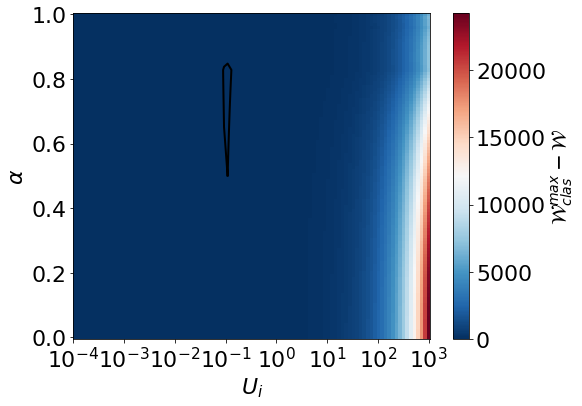

In [ ]:
# Plot of the results of the previous simulation

plt.figure(figsize=(8, 6))

mesh = plt.pcolormesh(U_irange/K, alpha, (work_matrix2 + bound_matrix2)/K, cmap='RdBu_r', shading='auto')

plt.xscale('log')

plt.contour(U_irange/K, alpha, (work_matrix2+bound_matrix2)/K, levels=[0], colors='black', linewidths=2)
cbar = plt.colorbar(mesh) 
cbar.ax.tick_params(labelsize=22) 

cbar.set_label(r'$\mathcal{W}^{max}_{clas} - \mathcal{W}$', fontsize=20)
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))

plt.xlabel(r'$U_i$', fontsize=22)
plt.ylabel(r'$\alpha$', fontsize=22)
plt.tick_params(axis="both", labelsize=22)


plt.show()